In [ ]:
!pip install scanpy==1.9.3 anndata==0.8.0
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install harmonypy
!pip install scvi-tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 20.7 MB/s eta 0:00:00
  

In [ ]:
import scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [ ]:
# import anndata as ad

data_path = "/content/drive/MyDrive/GP_datasets/Pancreas/Baron_Pancreas_Combined_Human_Mouse.h5ad"


In [ ]:
# read adata
adata = sc.read_h5ad(data_path)

In [ ]:
print(adata)

AnnData object with n_obs × n_vars = 9436 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'


In [ ]:
# check cell_types
adata.obs['cell_type'].value_counts()
print(adata.obs)

                                                barcode           cell_type  \
0-mouse_1                            AAGTGAAAG-CGACTCCT                beta   
1-mouse_1                             TGCAAGGG-GGCATGCT              ductal   
2-mouse_1                           GAGAGCCCAT-CTTCTGGA               delta   
3-mouse_1                             AAATCAGA-GTTGCACG             schwann   
4-mouse_1                           GAGGCGTTAG-GGCTACTA               delta   
...                                                 ...                 ...   
human4_lib3.final_cell_0697-human   GAGATCTCGG-GTCTCTCT  activated_stellate   
human4_lib3.final_cell_0698-human     GCTTACCT-ATGTTGGC               alpha   
human4_lib3.final_cell_0699-human  TGACACAGTTT-TTGTCGCC                beta   
human4_lib3.final_cell_0700-human   GACGACTCCT-CGCTAATA                beta   
human4_lib3.final_cell_0701-human     TGATGCCC-TTGCACGC              ductal   

                                  donor_batch      

## Normalization

In [ ]:
# make sure there is a counts layer for scvi
adata.layers["counts"] = adata.X

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # keep full dimension safe
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=4000,
    flavor="seurat_v3",
    layer="counts",
    subset=True,
    batch_key="species",  #
)

In [ ]:
import scvi
import scanpy as sc

# Make sure categorical columns are string type
# adata.obs["donor_id"] = adata.obs["donor_id"].astype(str)

# Prepare AnnData for SCVI
scvi.model.SCVI.setup_anndata(
    adata,
    layer = "counts",
    batch_key="species",
)

In [ ]:
vae = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")
vae.train(max_epochs=100, early_stopping=True)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [ ]:
adata.obsm["X_scVI"] = vae.get_latent_representation()

In [ ]:
# save embeddings to drive
adata.write("/content/drive/MyDrive/GP_datasets/Pancreas_combined_Human+Mouse_embeddings_scVI.h5ad")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi(adata, label_keys, embed_key,k_lisi=30):

    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]


    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        sil_scores[key] = silhouette_score(X, adata.obs[key].values)


    # Call compute_lisi
    lisi_scores = compute_lisi(X, metadata, label_colnames=label_keys)

    # Convert to DataFrame for easier handling
    lisi_df = pd.DataFrame(lisi_scores, columns=label_keys, index=adata.obs_names)

    # Combine results
    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.median().to_dict()
    }

    return scores

In [ ]:
label_keys = ["cell_type", "batch", "species"]
# Compute scores
scores = compute_silhouette_and_lisi(adata, label_keys, embed_key="X_scVI", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


Silhouette Scores: {'cell_type': np.float32(0.1294409), 'batch': np.float32(-0.006364674), 'species': np.float32(0.020526169)}
LISI Scores: {'cell_type': 1.0023906608542756, 'batch': 1.016114249462683, 'species': 1.014320190065861}


In [ ]:
# "Label Transfer"

train_out = "/content/drive/MyDrive/GP_datasets/Pancreas_combined_Human+Mouse_embeddings_scVI.h5ad"

adata = sc.read(train_out)

adata

AnnData object with n_obs × n_vars = 9436 × 4000
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'log1p'
    obsm: 'X_scVI'
    layers: 'counts'

#Human --> Mouse

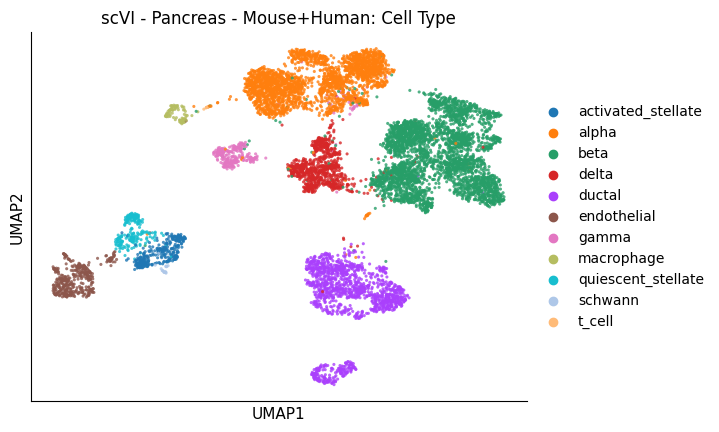

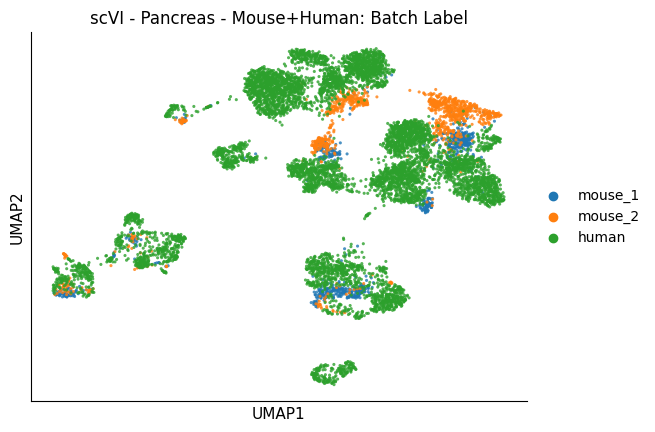

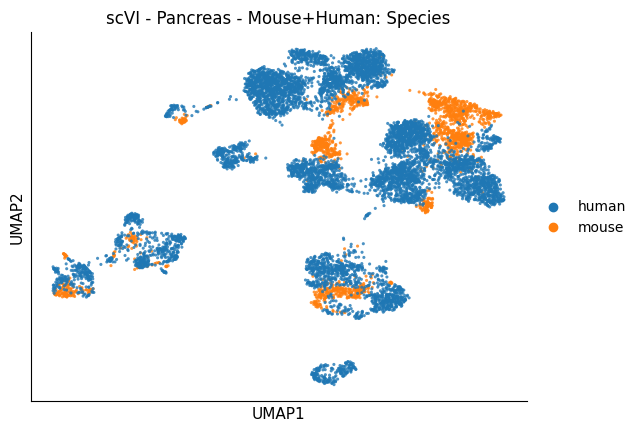

=== Logistic Regression ===
Accuracy: 0.867237687366167
                    precision    recall  f1-score   support

activated_stellate       0.35      1.00      0.52        14
             alpha       0.55      0.98      0.71       191
              beta       0.96      0.88      0.92       894
             delta       0.91      0.74      0.82       218
            ductal       0.93      0.93      0.93       275
       endothelial       1.00      1.00      1.00       139
             gamma       0.75      0.15      0.24        41
        macrophage       0.97      1.00      0.99        36
quiescent_stellate       0.96      0.57      0.72        47
           schwann       0.00      0.00      0.00         6
            t_cell       1.00      0.86      0.92         7

          accuracy                           0.87      1868
         macro avg       0.76      0.74      0.71      1868
      weighted avg       0.90      0.87      0.87      1868



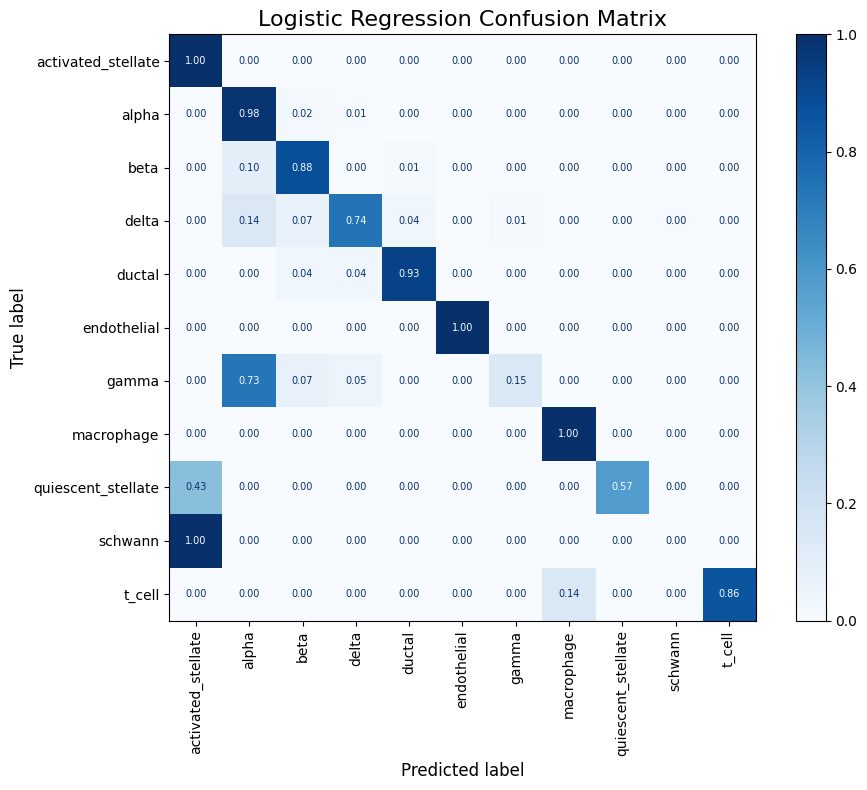


=== k-NN ===
Accuracy: 0.8752676659528907
                    precision    recall  f1-score   support

activated_stellate       0.47      1.00      0.64        14
             alpha       0.52      0.98      0.68       191
              beta       0.99      0.86      0.92       894
             delta       0.91      0.78      0.84       218
            ductal       0.96      0.99      0.97       275
       endothelial       0.99      0.98      0.99       139
             gamma       0.53      0.20      0.29        41
        macrophage       0.97      1.00      0.99        36
quiescent_stellate       0.95      0.81      0.87        47
           schwann       0.00      0.00      0.00         6
            t_cell       1.00      1.00      1.00         7

          accuracy                           0.88      1868
         macro avg       0.75      0.78      0.74      1868
      weighted avg       0.91      0.88      0.88      1868



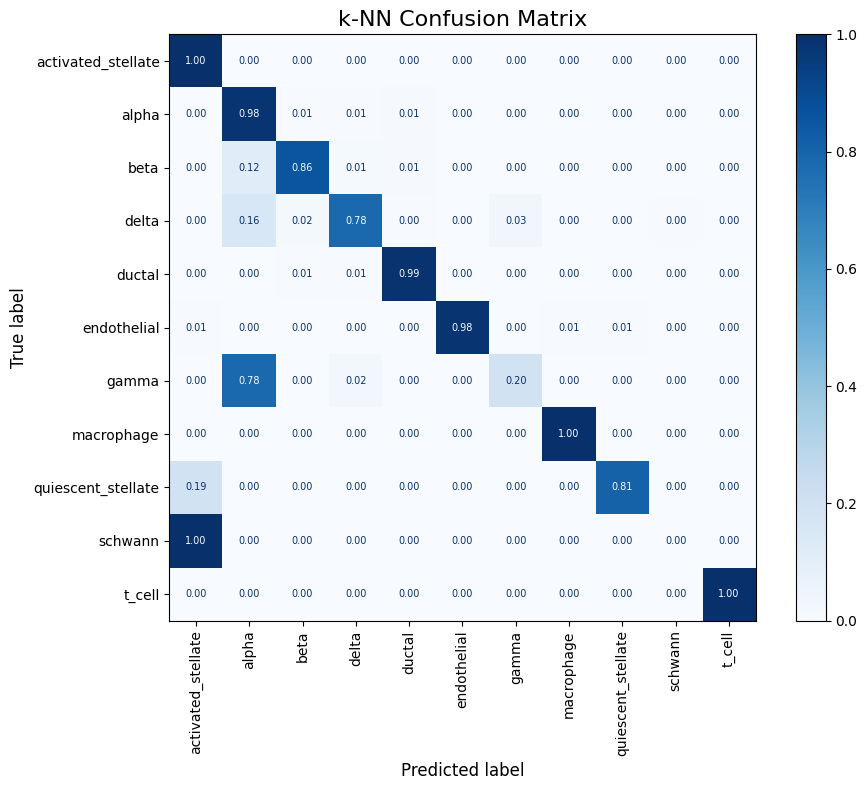

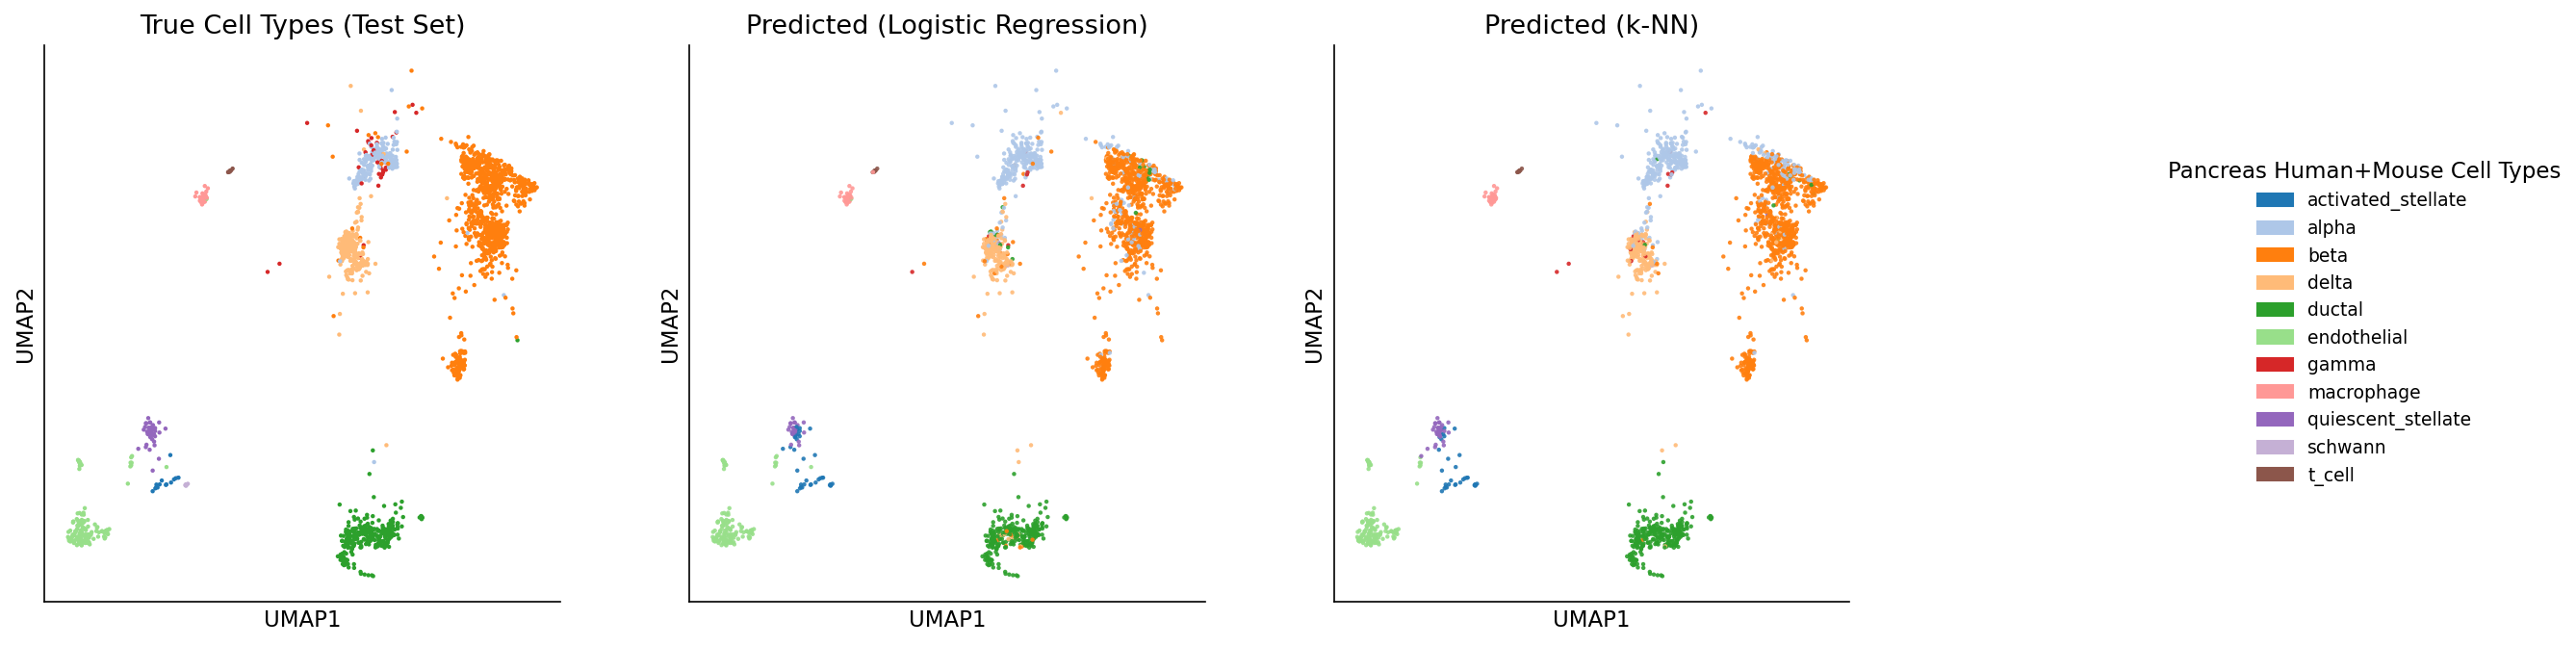

In [ ]:

## Visualization

from sklearn.metrics import ConfusionMatrixDisplay


sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)

ax = sc.pl.umap(
    adata,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Pancreas - Mouse+Human: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata,
    color='batch',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Pancreas - Mouse+Human: Batch Label"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata,
    color='species',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Pancreas - Mouse+Human: Species"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier using Geneformer embeddings  3 batches for train and 1 for test

train_data = adata[adata.obs["species"] != "mouse"]
test_data  = adata[adata.obs["species"] == "mouse"]

X_train = train_data.obsm["X_scVI"]
X_test  = test_data.obsm["X_scVI"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Human+Mouse Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()

## Mouse ---> Human

=== Logistic Regression ===
Accuracy: 0.8084038054968288
                    precision    recall  f1-score   support

activated_stellate       0.99      0.65      0.79       284
             alpha       0.98      0.59      0.74      2326
              beta       0.72      0.97      0.83      2525
             delta       0.67      0.74      0.70       601
            ductal       0.95      0.94      0.95      1077
       endothelial       0.95      1.00      0.97       252
             gamma       0.61      0.70      0.65       255
        macrophage       1.00      0.80      0.89        55
quiescent_stellate       0.67      0.96      0.79       173
           schwann       0.33      0.38      0.36        13
            t_cell       0.50      0.43      0.46         7

          accuracy                           0.81      7568
         macro avg       0.76      0.74      0.74      7568
      weighted avg       0.85      0.81      0.80      7568



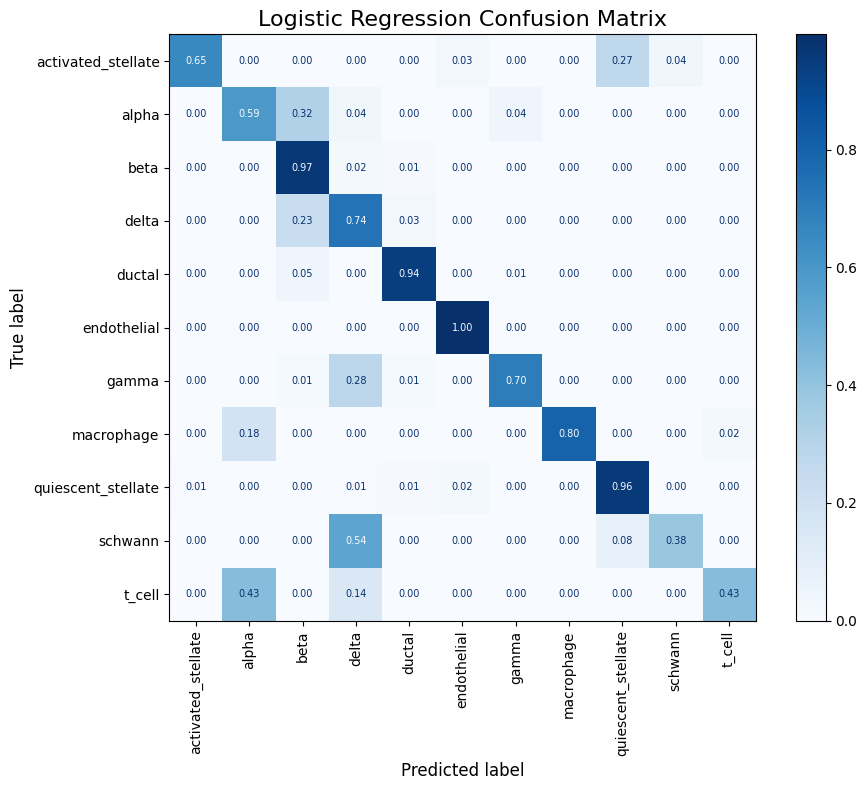


=== k-NN ===
Accuracy: 0.7521141649048626
                    precision    recall  f1-score   support

activated_stellate       1.00      0.70      0.82       284
             alpha       0.98      0.48      0.64      2326
              beta       0.70      0.94      0.80      2525
             delta       0.56      0.69      0.62       601
            ductal       0.79      0.97      0.87      1077
       endothelial       0.90      1.00      0.95       252
             gamma       0.62      0.29      0.40       255
        macrophage       0.76      1.00      0.87        55
quiescent_stellate       0.63      0.98      0.77       173
           schwann       0.57      0.62      0.59        13
            t_cell       0.30      1.00      0.47         7

          accuracy                           0.75      7568
         macro avg       0.71      0.79      0.71      7568
      weighted avg       0.80      0.75      0.74      7568



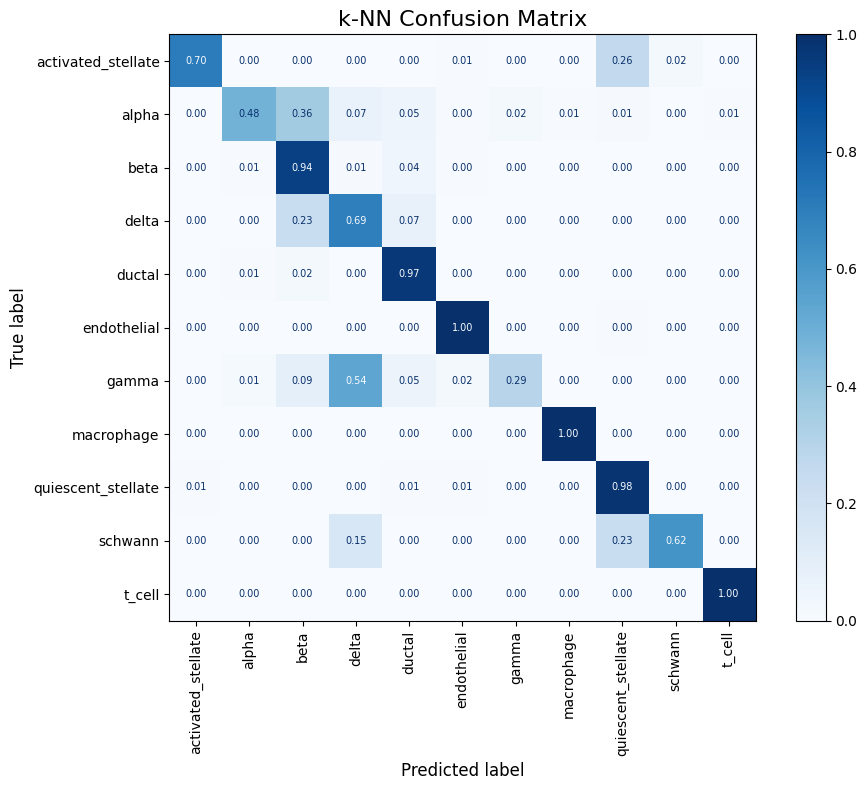

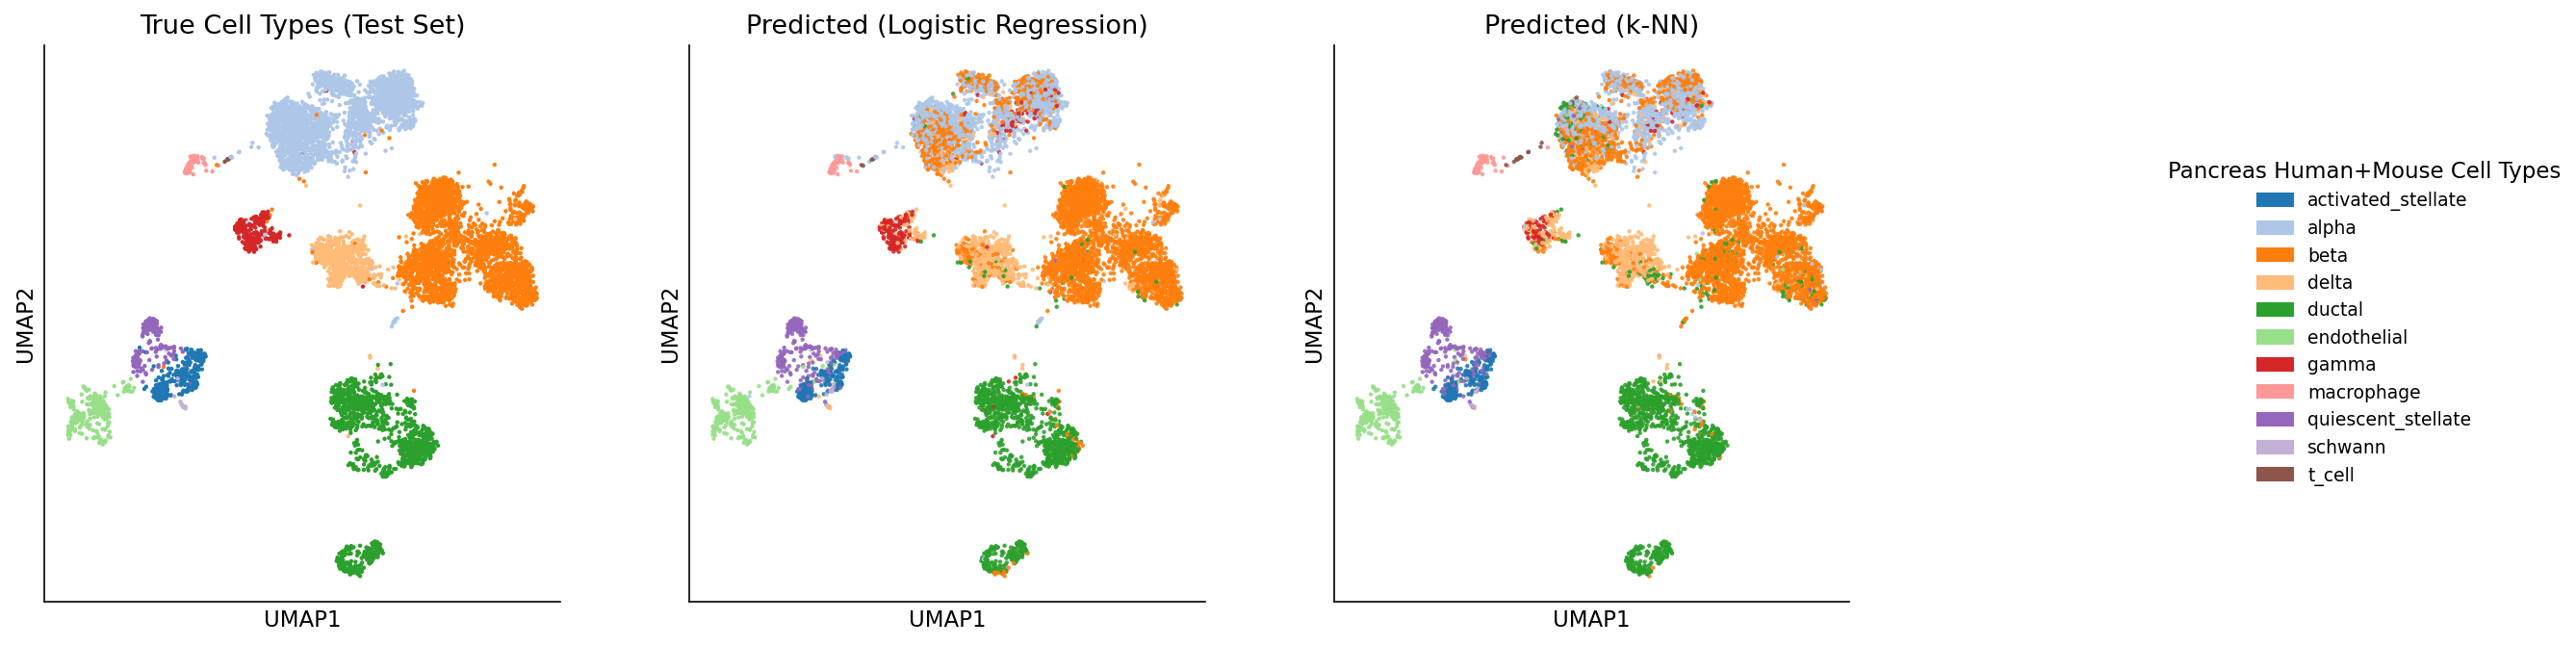

In [ ]:

## Visualization

from sklearn.metrics import ConfusionMatrixDisplay

# ## Build a cell-type classifier

train_data3 = adata[adata.obs["species"] == "mouse"]
test_data3  = adata[adata.obs["species"] != "mouse"]

X_train3 = train_data3.obsm["X_scVI"]
X_test3  = test_data3.obsm["X_scVI"]

y_train3 = train_data3.obs["cell_type"]
y_test3  = test_data3.obs["cell_type"]


# logistic regression
clf3 = LogisticRegression(max_iter=300, solver='lbfgs')

clf3.fit(X_train3, y_train3)
y_pred_lr3 = clf3.predict(X_test3)

# KNN
knn3 = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn3.fit(X_train3, y_train3)
y_pred_knn3 = knn3.predict(X_test3)

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test3, y_pred_lr3))
print(classification_report(y_test3, y_pred_lr3))
plot_cm(y_test3, y_pred_lr3, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test3, y_pred_knn3))
print(classification_report(y_test3, y_pred_knn3))
plot_cm(y_test3, y_pred_knn3, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data3.obs["y_pred_lr3"] = y_pred_lr3
test_data3.obs["y_pred_knn3"] = y_pred_knn3

# Fill missing values
test_data3.obs["y_pred_lr3"] = test_data3.obs["y_pred_lr3"].astype(str).fillna("Unassigned")
test_data3.obs["y_pred_knn3"] = test_data3.obs["y_pred_knn3"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data3.obs["cell_type"] = test_data3.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data3.obs["y_pred_lr3"] = test_data3.obs["y_pred_lr3"].astype("category")
test_data3.obs["y_pred_knn3"] = test_data3.obs["y_pred_knn3"].astype("category")

# Unified label set
all_labels3 = sorted(
    set(test_data3.obs["cell_type"].cat.categories)
    | set(test_data3.obs["y_pred_lr3"].cat.categories)
    | set(test_data3.obs["y_pred_knn3"].cat.categories)
)

# Force same category order
test_data3.obs["cell_type"] = test_data3.obs["cell_type"].cat.set_categories(all_labels3)
test_data3.obs["y_pred_lr3"] = test_data3.obs["y_pred_lr3"].cat.set_categories(all_labels3)
test_data3.obs["y_pred_knn3"] = test_data3.obs["y_pred_knn3"].cat.set_categories(all_labels3)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels3)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data3, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data3, color="y_pred_lr3", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data3, color="y_pred_knn3", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Human+Mouse Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()